# **Sustainability Aware Asset Management :**
# **Portfolio Allocation with a Carbon Objective**

To reproduce the analysis, please follow the steps below :

- Clone the project repository locally.

- Create the environment: 

   conda env create -f environment.yml

- Activate the environment:

   conda activate saam-project

- Select the newly created kernel in the notebook.

- Run all cells sequentially, from top to bottom.

## **Part I - Standard Portfolio Allocation**
**The first part of the project consists of building a portfolio based on the minimum-variance criterion.**

In [48]:
import pandas as pd
import numpy as np

#Define the path to the cleaned datasets
path = "../data/cleaned/"

#Load the cleaned datasets
ri_m = pd.read_csv(path + "RI_M_cleaned.csv", sep=";", na_values="N/A")
co2 = pd.read_csv(path + "CO2_S1_cleaned.csv", sep=";", na_values="N/A")
static = pd.read_csv(path + "STATIC_cleaned.csv", sep=";", na_values="N/A")

### **1) Data cleaning**

Data cleaning was necessary to design a meaningful investment strategy. 

The datasets used in this notebook are cleaned versions of the original Datastream files, based on the cleaning steps required by the project :

- group assignment: region and climate strategy (done in Excel)
- missing revenues and CO2 emissions (done in Excel)
- missing prices (done in Excel)
- missing values (done in Excel)
- low prices (done in Excel)

The table below shows how many firms remain after these initial cleaning steps :

In [49]:
print("static shape:", static.shape)
pd.concat([static.head(), static.tail()])

static shape: (618, 4)


,ISIN,NAME,Country,Region
0,AT000000STR1,STRABAG SE,AT,EUR
1,AT00000VIE62,FLUGHAFEN WIEN,AT,EUR
2,AT0000606306,RAIFFEISEN BANK INTL.,AT,EUR
3,AT0000652011,ERSTE GROUP BANK,AT,EUR
4,AT0000720008,TELEKOM AUSTRIA,AT,EUR
613,SE0020050417,BOLIDEN ORD SHS,SE,EUR
614,US0528001094,AUTOLIV,SE,EUR
615,US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,IL,EUR
616,US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,IL,EUR
617,US91822M5022,VEON ADR 1:25,NL,EUR


- stale prices (addressed later in Section 2.1)
- insufficient return history (addressed later in Section 2.1)
- carbon data availability (addressed later in Section 2.1)
- allocation time horizon (addressed later in Section 2.1)

A more detailed description of the cleaning procedure is provided in the report.

We check that the cleaned datasets contain the same number of firms and then organise the matrices into a more suitable format :

We keep 2025 in the CO2 dataset for carry-forward purposes, but not to construct portfolio weights for 2026 ...

In [50]:
print("co2 shape:", co2.shape)
co2.head()

co2 shape: (618, 29)


,NAME,ISIN,1999,2000,2001,2002,2003,2004,2005,2006,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246,876651,844209,833816,742063,771799,813242,819934,790336,790336
1,FLUGHAFEN WIEN,AT00000VIE62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796,8455,8958,9648,4745,5663,7567,9027,9847,9847
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027,6270,7696,7455,6392,4827,6049,12403,9375,9375
3,ERSTE GROUP BANK,AT0000652011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630,27967,27297,29950,24929,21530,20707,18701,16803,16803
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"14813,3",...,27419,27867,23833,22758,23766,23732,24048,20964,18807,18807


In [51]:
#Read the year labels as integers
years = pd.to_numeric(co2.columns[2:], errors="raise").astype(int)

#Create a copy of co2 and assign the year labels to the columns
co2_wide = co2.copy()
co2_wide.columns = ["NAME", "ISIN"] + list(years)

#Use ISIN and NAME as row identifiers and sort the columns by year
co2_wide = co2_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

#Transform the CO2 values into numeric format
co2_wide = co2_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("co2_wide shape:", co2_wide.shape)
pd.concat([co2_wide.head(), co2_wide.tail()])

co2_wide shape: (618, 27)


,,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,836246.0,876651.00,844209.00,833816.0,742063.0,771799.00,813242.0,819934.0,790336.0,790336.0
AT00000VIE62,FLUGHAFEN WIEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11796.0,8455.00,8958.00,9648.0,4745.0,5663.00,7567.0,9027.0,9847.0,9847.0
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6027.0,6270.00,7696.00,7455.0,6392.0,4827.00,6049.0,12403.0,9375.0,9375.0
AT0000652011,ERSTE GROUP BANK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22630.0,27967.00,27297.00,29950.0,24929.0,21530.00,20707.0,18701.0,16803.0,16803.0
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14813.3,29430.22,16027.64,...,27419.0,27867.00,23833.00,22758.0,23766.0,23732.00,24048.0,20964.0,18807.0,18807.0
SE0020050417,BOLIDEN ORD SHS,NaN,NaN,NaN,NaN,NaN,NaN,703000.0,189936.0,413000.00,473000.00,...,594000.0,605000.00,644000.00,598000.0,544000.0,624794.00,629000.0,627845.0,657646.0,657646.0
US0528001094,AUTOLIV,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,102103.61,119092.85,107000.0,98000.0,103000.00,102000.0,95000.0,75000.0,75000.0
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13392.0,13392.00,5170.00,4833.0,3854.0,4238.28,4569.0,4569.0,4569.0,4569.0
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,392268.0,458755.00,372604.00,299146.0,290471.0,282044.00,253306.0,242056.0,243603.0,243603.0


... since the full set of monthly returns for 2026 is not available, as shown below.

In [52]:
print("ri_m shape:", ri_m.shape)
ri_m.head()

ri_m shape: (618, 316)


,NAME,ISIN,31/12/99,31/01/00,29/02/00,31/03/00,28/04/00,31/05/00,30/06/00,31/07/00,...,30/04/25,30/05/25,30/06/25,31/07/25,29/08/25,30/09/25,31/10/25,28/11/25,31/12/25,30/01/26
0,STRABAG SE,AT000000STR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"430,27","430,83","479,46","477,35","465,06","461,5","396,65","452,87","481,49","526,88"
1,FLUGHAFEN WIEN,AT00000VIE62,"147,79","156,25","153,83","158,62","137,27","148,95","159,68","151,08",...,"2339,19","2371,03","2478,96","2417,14","2434,84","2425,66","2409,99","2533,4","2591,68","2587,67"
2,RAIFFEISEN BANK INTL.,AT0000606306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"113,07","129,28","128,7","123,36","140,73","146,05","158,13","171,78","190,56","215,11"
3,ERSTE GROUP BANK,AT0000652011,"102,94","94,91","97,74","100,5","96,13","97,86","102,06","102,43",...,"1237,75","1536,73","1621,45","1761,42","1818,07","1867,75","1979,03","2087,48","2308,86","2488,84"
4,TELEKOM AUSTRIA,AT0000720008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"343,5","359,25","383,12","360,02","370,54","361,64","360,3","350,11","357,49","360,93"


In [53]:
#Convert the column labels into dates
dates = pd.to_datetime(ri_m.columns[2:], format="%d/%m/%y", errors="coerce")

#Create a copy of ri_m and assign the date labels to the columns
ri_m_wide = ri_m.copy()
ri_m_wide.columns = ["NAME", "ISIN"] + list(dates)

#Use ISIN and NAME as row identifiers and sort the columns by date
ri_m_wide = ri_m_wide.set_index(["ISIN", "NAME"]).sort_index(axis=1)

#Transform the return index values into numeric format
ri_m_wide = ri_m_wide.apply(
    lambda col: pd.to_numeric(
        col.astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
)

print("ri_m_wide shape:", ri_m_wide.shape)
pd.concat([ri_m_wide.head(), ri_m_wide.tail()])

ri_m_wide shape: (618, 314)


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,430.27,430.83,479.46,477.35,465.06,461.50,396.65,452.87,481.49,526.88
AT00000VIE62,FLUGHAFEN WIEN,147.79,156.25,153.83,158.62,137.27,148.95,159.68,151.08,153.35,161.64,...,2339.19,2371.03,2478.96,2417.14,2434.84,2425.66,2409.99,2533.40,2591.68,2587.67
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,113.07,129.28,128.70,123.36,140.73,146.05,158.13,171.78,190.56,215.11
AT0000652011,ERSTE GROUP BANK,102.94,94.91,97.74,100.50,96.13,97.86,102.06,102.43,106.82,102.31,...,1237.75,1536.73,1621.45,1761.42,1818.07,1867.75,1979.03,2087.48,2308.86,2488.84
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,343.50,359.25,383.12,360.02,370.54,361.64,360.30,350.11,357.49,360.93
SE0020050417,BOLIDEN ORD SHS,16.00,15.72,11.76,11.49,8.90,8.70,7.67,6.87,5.99,5.73,...,37.21,37.84,37.53,37.37,41.71,49.32,54.77,58.06,67.73,85.79
US0528001094,AUTOLIV,85.34,77.68,79.83,87.89,82.58,80.52,70.78,71.70,68.13,57.61,...,678.86,753.90,820.48,817.91,909.71,911.70,862.24,877.52,882.80,901.69
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,159.82,113.50,105.00,102.69,66.01,44.01,58.68,48.64,58.68,47.48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,1649.72,1506.25,1985.68,1718.26,2027.13,2483.16,2555.90,2801.43,2796.27,3376.35,...,3867.12,4183.76,4178.77,3852.16,4582.69,5036.47,5106.29,6704.49,7781.60,8497.18


### **2) Minimum-Variance Portfolio Allocation**

The return index values are converted into returns using the simple return definition, $R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1$.

Returns at date *t* are then collected in the vector $R_t = (R_{1,t}, \ldots, R_{N,t})$, where $N$ denotes the number of firms.

In [54]:
#Convert return index values into simple returns by computing percentage changes over time
returns_wide = ri_m_wide.pct_change(axis=1, fill_method=None)

print("returns_wide shape:", returns_wide.shape)
pd.concat([returns_wide.head(), returns_wide.tail()])

returns_wide shape: (618, 314)


,,1999-12-31 00:00:00,2000-01-31 00:00:00,2000-02-29 00:00:00,2000-03-31 00:00:00,2000-04-28 00:00:00,2000-05-31 00:00:00,2000-06-30 00:00:00,2000-07-31 00:00:00,2000-08-31 00:00:00,2000-09-29 00:00:00,...,2025-04-30 00:00:00,2025-05-30 00:00:00,2025-06-30 00:00:00,2025-07-31 00:00:00,2025-08-29 00:00:00,2025-09-30 00:00:00,2025-10-31 00:00:00,2025-11-28 00:00:00,2025-12-31 00:00:00,2026-01-30 00:00:00
ISIN,NAME,,,,,,,,,,,,,,,,,,,,,
AT000000STR1,STRABAG SE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.230679,0.001302,0.112875,-0.004401,-0.025746,-0.007655,-0.140520,0.141737,0.063197,0.094270
AT00000VIE62,FLUGHAFEN WIEN,NaN,0.057243,-0.015488,0.031138,-0.134598,0.085088,0.072038,-0.053858,0.015025,0.054059,...,0.040736,0.013612,0.045520,-0.024938,0.007323,-0.003770,-0.006460,0.051208,0.023005,-0.001547
AT0000606306,RAIFFEISEN BANK INTL.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.041736,0.143363,-0.004486,-0.041492,0.140807,0.037803,0.082711,0.086321,0.109326,0.128831
AT0000652011,ERSTE GROUP BANK,NaN,-0.078007,0.029818,0.028238,-0.043483,0.017996,0.042918,0.003625,0.042859,-0.042221,...,-0.018134,0.241551,0.055130,0.086324,0.032162,0.027326,0.059580,0.054800,0.106051,0.077952
AT0000720008,TELEKOM AUSTRIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.135199,0.045852,0.066444,-0.060294,0.029221,-0.024019,-0.003705,-0.028282,0.021079,0.009623
SE0020050417,BOLIDEN ORD SHS,NaN,-0.017500,-0.251908,-0.022959,-0.225413,-0.022472,-0.118391,-0.104302,-0.128093,-0.043406,...,-0.057736,0.016931,-0.008192,-0.004263,0.116136,0.182450,0.110503,0.060069,0.166552,0.266647
US0528001094,AUTOLIV,NaN,-0.089759,0.027678,0.100965,-0.060416,-0.024946,-0.120964,0.012998,-0.049791,-0.154411,...,0.054049,0.110538,0.088314,-0.003132,0.112237,0.002188,-0.054250,0.017721,0.006017,0.021398
US70211M1099,PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23,NaN,-0.289826,-0.074890,-0.022000,-0.357192,-0.333283,0.333333,-0.171097,0.206414,-0.190866,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
US8816242098,TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1,NaN,-0.086966,0.318294,-0.134674,0.179757,0.224963,0.029293,0.096064,-0.001842,0.207448,...,0.009110,0.081880,-0.001193,-0.078159,0.189642,0.099020,0.013863,0.312987,0.160655,0.091958


#### **2.1) Investment set** 

This section defines the investment sets used to construct out-of-sample portfolios.

The allocation exercise is carried out from the end of 2013 to the end of 2024.

At the end of each year \(Y\), the investment set is defined as the set of firms that satisfy the following criteria:

- sufficient return history to compute expected returns and the covariance matrix (at least 3 years of available monthly returns over the past 10 years)
- no stale prices (the share of zero returns, computed over available monthly returns, must not exceed 50%)
- availability of carbon data at the end of year \(Y\)
- a valid return index observation in December of year \(Y\)

If a firm does not satisfy these criteria at the end of year \(Y\), it is excluded from that year's investment set.

The table below shows the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix:

In [55]:
# We rebalance once a year, from end-2013 to end-2024
years = range(2013, 2025)

# Main filters used to define the investment set
tau = 120              # 10 years of monthly returns
min_obs = 36           # at least 3 years of available monthly returns
stale_threshold = 0.50 # max 50% of zero returns among available returns

# Keep only firms that exist in all panels we need later
common_firms = ri_m_wide.index.intersection(returns_wide.index).intersection(co2_wide.index)

ri_panel = ri_m_wide.loc[common_firms].copy()
ret_panel = returns_wide.loc[common_firms].copy()
co2_panel = co2_wide.loc[common_firms].copy()

# Save the December date for each formation year
year_end_dec = {}

for Y in years:
    dec_dates = [d for d in ri_panel.columns if d.year == Y and d.month == 12]
    if len(dec_dates) == 0:
        raise ValueError(f"No December date found for year {Y}")
    year_end_dec[Y] = max(dec_dates)

# Same investment-set logic for every section of the notebook
def get_investment_set(Y):
    
    dec_date = year_end_dec[Y]
    start_date = dec_date - pd.DateOffset(months=119)

    # 120-month window ending in December of year Y
    window_cols = [d for d in ret_panel.columns if start_date <= d <= dec_date]
    returns_window = ret_panel[window_cols]

    # 1) enough return history
    n_available = returns_window.notna().sum(axis=1)
    enough_history = n_available >= min_obs

    # 2) not too many zero returns
    zero_counts = returns_window.eq(0).sum(axis=1)
    zero_share = zero_counts / n_available.replace(0, np.nan)
    not_stale = zero_share <= stale_threshold

    # 3) carbon data available at the end of year Y
    if Y in co2_panel.columns:
        has_carbon = co2_panel[Y].notna()
    else:
        has_carbon = pd.Series(False, index=co2_panel.index)

    # 4) valid RI in December of year Y
    valid_dec_price = ri_panel[dec_date].notna()

    keep = enough_history & not_stale & has_carbon & valid_dec_price

    return common_firms[keep.fillna(False)]

# Store the yearly investment sets and estimation inputs
investment_sets = {}
mu_dict = {}
sigma_dict = {}

for Y in years:
    
    eligible = get_investment_set(Y)
    dec_date = year_end_dec[Y]
    start_date = dec_date - pd.DateOffset(months=119)

    window_cols = [d for d in ret_panel.columns if start_date <= d <= dec_date]
    est_window = ret_panel.loc[eligible, window_cols]

    investment_sets[Y] = eligible
    mu_dict[Y] = est_window.mean(axis=1)
    sigma_dict[Y] = est_window.T.cov()

The table below shows the size of the investment set over time, together with the dimensions of the expected return vector and covariance matrix :

In [56]:
summary_table = pd.DataFrame({
    "Number of firms": {Y: len(investment_sets[Y]) for Y in years},
    "Expected return vector": {Y: mu_dict[Y].shape for Y in years},
    "Covariance matrix": {Y: sigma_dict[Y].shape for Y in years},
})

summary_table

,Number of firms,Expected return vector,Covariance matrix
2013,477,"(477,)","(477, 477)"
2014,493,"(493,)","(493, 493)"
2015,509,"(509,)","(509, 509)"
2016,515,"(515,)","(515, 515)"
2017,529,"(529,)","(529, 529)"
2018,549,"(549,)","(549, 549)"
2019,574,"(574,)","(574, 574)"
2020,593,"(593,)","(593, 593)"
2021,600,"(600,)","(600, 600)"
2022,592,"(592,)","(592, 592)"


As time passes, an increasing number of firms are included in the investment set.

The outputs below show the vectors of expected returns for 2013 and 2024, the first and last allocation years : 

In [57]:
mu_dict[2013].head(477)

ISIN          NAME                                        
AT000000STR1  STRABAG SE                                     -0.000342
AT0000606306  RAIFFEISEN BANK INTL.                           0.009210
AT0000652011  ERSTE GROUP BANK                                0.012839
AT0000720008  TELEKOM AUSTRIA                                 0.002051
AT0000743059  OMV                                             0.017438
                                                                ...   
SE0018012635  WIHLBORGS FASTIGHETER                           0.017928
SE0020050417  BOLIDEN ORD SHS                                 0.027158
US70211M1099  PARTNER COMMS.ADR 1:1 DEAD - DELIST.22/09/23    0.012070
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1          0.004620
US91822M5022  VEON ADR 1:25                                   0.005762
Length: 477, dtype: float64

In [58]:
mu_dict[2024].head(613)

ISIN          NAME                                  
AT000000STR1  STRABAG SE                                0.013689
AT00000VIE62  FLUGHAFEN WIEN                            0.011943
AT0000606306  RAIFFEISEN BANK INTL.                     0.013040
AT0000652011  ERSTE GROUP BANK                          0.017128
AT0000720008  TELEKOM AUSTRIA                           0.007373
                                                          ...   
SE0018012635  WIHLBORGS FASTIGHETER                     0.012165
SE0020050417  BOLIDEN ORD SHS                           0.013461
US0528001094  AUTOLIV                                   0.008456
US8816242098  TEVA PHARMACEUTICAL INDUSTRIES ADR 1:1    0.002298
US91822M5022  VEON ADR 1:25                             0.010270
Length: 564, dtype: float64

The outputs below show the covariance matrices for the first five firms in 2013 and 2024, the first and last allocation years :

In [59]:
#Modify the slicing to display the full covariance matrix
sigma_dict[2013].iloc[:5, :5]

,ISIN,AT000000STR1,AT0000606306,AT0000652011,AT0000720008,AT0000743059
,NAME,STRABAG SE,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA,OMV
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.020084,0.015876,0.018473,0.007008,0.009323
AT0000606306,RAIFFEISEN BANK INTL.,0.015876,0.020598,0.017885,0.005767,0.008832
AT0000652011,ERSTE GROUP BANK,0.018473,0.017885,0.020441,0.005075,0.007458
AT0000720008,TELEKOM AUSTRIA,0.007008,0.005767,0.005075,0.007252,0.004296
AT0000743059,OMV,0.009323,0.008832,0.007458,0.004296,0.011011


In [60]:
# Modify the slicing to display the full covariance matrix
sigma_dict[2024].iloc[:5, :5]

,ISIN,AT000000STR1,AT00000VIE62,AT0000606306,AT0000652011,AT0000720008
,NAME,STRABAG SE,FLUGHAFEN WIEN,RAIFFEISEN BANK INTL.,ERSTE GROUP BANK,TELEKOM AUSTRIA
ISIN,NAME,,,,,
AT000000STR1,STRABAG SE,0.004753,0.002694,0.003769,0.003640,0.001442
AT00000VIE62,FLUGHAFEN WIEN,0.002694,0.005988,0.003277,0.003457,0.001465
AT0000606306,RAIFFEISEN BANK INTL.,0.003769,0.003277,0.012463,0.007943,0.003103
AT0000652011,ERSTE GROUP BANK,0.003640,0.003457,0.007943,0.010303,0.002418
AT0000720008,TELEKOM AUSTRIA,0.001442,0.001465,0.003103,0.002418,0.003151


#### **2.2) Minimum-variance portfolio allocation**

In [61]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
from scipy.optimize import minimize

warnings.filterwarnings("ignore", category=RuntimeWarning)

# 2.2 uses the objects created in Section 2.1
required_objects = ["years", "investment_sets", "year_end_dec", "ri_panel", "ret_panel"]
for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Section 2.1 must be run first. Missing object: {obj}")

# Paths
data_dir = Path("../data/cleaned")
rf_file = data_dir / "RF.csv"

output_dir = Path("../results/outputs_minvar")
output_dir.mkdir(parents=True, exist_ok=True)

# Simple settings
ridge = 1e-8
solver_maxiter = 2000
ftol = 1e-12
csv_sep = ";"


def parse_rf_dates(date_series):
    raw = date_series.astype(str).str.strip()
    numeric = pd.to_numeric(raw, errors="coerce")

    if numeric.notna().all():
        return pd.DatetimeIndex(pd.to_datetime(numeric, unit="D", origin="1899-12-30"))

    return pd.DatetimeIndex(pd.to_datetime(raw, dayfirst=True, errors="coerce"))


def solve_minvar(cov_matrix):
    n = cov_matrix.shape[0]

    if n == 0:
        raise ValueError("Covariance matrix is empty.")
    if n == 1:
        return pd.Series([1.0], index=cov_matrix.index)

    Sigma = cov_matrix.to_numpy(dtype=float)
    Sigma = Sigma + ridge * np.eye(n)

    x0 = np.repeat(1 / n, n)

    def objective(w):
        return float(w @ Sigma @ w)

    constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]
    bounds = [(0.0, 1.0)] * n

    res = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": solver_maxiter, "ftol": ftol, "disp": False},
    )

    if not res.success:
        raise ValueError(f"Optimization failed: {res.message}")

    w = pd.Series(res.x, index=cov_matrix.index)
    w = w / w.sum()
    return w


def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()


# Load risk-free rate
rf_raw = pd.read_csv(rf_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

if rf_raw.shape[1] < 2:
    raise ValueError("RF.csv must contain at least one date column and one RF column.")

rf = rf_raw.copy()
rf.columns = ["date_code", "RF"]

# In your file, dates are stored as YYYYMM
rf["date_code"] = rf["date_code"].astype(str).str.strip()
rf["date"] = pd.to_datetime(rf["date_code"], format="%Y%m") + pd.offsets.MonthEnd(0)

# RF values are written with comma decimals and are in percent
rf["RF"] = pd.to_numeric(
    rf["RF"].astype(str).str.replace(",", ".", regex=False),
    errors="coerce"
) / 100.0

rf_series = rf.set_index("date")["RF"].sort_index()
rf_series = rf_series.loc[rf_series.index <= pd.Timestamp("2025-12-31")]

# Convert to decimals if needed
if len(rf_series.dropna()) > 0 and rf_series.dropna().median() > 1:
    rf_series = rf_series / 100.0


# Build a delisting-event map from your cleaned monthly RI data
# In your file, delisted names are usually tagged in the NAME field
# and the RI series stops after the last valid month.
delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
delist_event_month = {}

for asset in ri_panel.index:
    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date


print(f"Detected {len(delist_event_month)} delisting/suspension event months in RI_M.")


investment_set_rows = []
weights_long_rows = []
oos_rows = []
mv_weights = {}

for Y in years:
    print(f"Formation year {Y} -> OOS year {Y + 1}")

    eligible = investment_sets[Y]
    dec_date = year_end_dec[Y]
    start_date = dec_date - pd.DateOffset(months=119)

    window_cols = [d for d in ret_panel.columns if start_date <= d <= dec_date]
    est_window = ret_panel.loc[eligible, window_cols]

    investment_set_rows.append({
        "formation_year": Y,
        "n_eligible": len(eligible)
    })

    if len(eligible) == 0:
        print(f"  Warning: no eligible firms for year {Y}")
        continue

    # Pairwise covariance on available data
    Sigma = est_window.T.cov()

    # Keep only assets for which the covariance block is fully usable
    valid_assets = Sigma.index[Sigma.notna().all(axis=1)]
    Sigma = Sigma.loc[valid_assets, valid_assets]

    if Sigma.empty:
        print(f"  Warning: covariance matrix is empty for year {Y}")
        continue

    w0 = solve_minvar(Sigma)
    mv_weights[Y] = w0

    for (isin, name), w in w0.items():
        weights_long_rows.append({
            "formation_year": Y,
            "oos_year": Y + 1,
            "ISIN": isin,
            "NAME": name,
            "weight": w
        })

    oos_months = sorted([d for d in ret_panel.columns if d.year == Y + 1])
    if len(oos_months) == 0:
        continue

    current_weights = w0.copy()

    for dt in oos_months:
        r_t = ret_panel.loc[current_weights.index, dt].copy()

        # For your data:
        # - if a stock is tagged DEAD/DELIST/SUSP
        # - and this month is the first missing RI month after the last valid one
        # then we record a -100% return for that month only
        forced_delist_assets = []
        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        # All other NaN values stay as missing data
        valid = r_t.notna() & current_weights.notna()
        r_t = r_t[valid]
        w_t = current_weights[valid]

        if len(w_t) == 0:
            oos_rows.append({
                "date": dt,
                "formation_year": Y,
                "oos_year": Y + 1,
                "portfolio_return": np.nan
            })
            continue

        # Re-normalize the observed weights for the current month
        w_t = w_t / w_t.sum()

        rp_t = float((w_t * r_t).sum())

        oos_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": rp_t
        })

        # Passive weight update inside the year
        denom = 1.0 + rp_t

        if abs(denom) > 1e-12:
            current_weights = w_t * (1.0 + r_t) / denom
            total = current_weights.sum()

            if abs(total) > 1e-12:
                current_weights = current_weights / total
            else:
                current_weights = pd.Series(
                    np.repeat(1 / len(w_t), len(w_t)),
                    index=w_t.index
                )
        else:
            current_weights = pd.Series(
                np.repeat(1 / len(w_t), len(w_t)),
                index=w_t.index
            )


investment_set_sizes = pd.DataFrame(investment_set_rows)
weights_by_year_long = pd.DataFrame(weights_long_rows)

minvar_monthly_returns = pd.DataFrame(oos_rows).sort_values("date").reset_index(drop=True)

if minvar_monthly_returns.empty:
    raise ValueError("No out-of-sample minimum-variance returns were produced.")

minvar_monthly_returns["date"] = pd.to_datetime(minvar_monthly_returns["date"])
minvar_monthly_returns = minvar_monthly_returns[
    (minvar_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (minvar_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

minvar_monthly_returns["cumulative_index"] = (
    1.0 + minvar_monthly_returns["portfolio_return"]
).cumprod()

minvar_cumulative_returns = minvar_monthly_returns[
    ["date", "formation_year", "oos_year", "portfolio_return", "cumulative_index"]
].copy()

full_months = pd.date_range("2014-01-31", "2025-12-31", freq="ME")
template_ready = pd.DataFrame({"date": full_months})
template_ready = template_ready.merge(
    minvar_monthly_returns[["date", "portfolio_return"]],
    on="date",
    how="left"
)
template_ready["date_str"] = template_ready["date"].dt.strftime("%Y-%m")
template_ready = template_ready[["date_str", "portfolio_return"]]

r = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index().dropna()

# Align RF and portfolio returns by month, not by exact timestamp
r_month = r.copy()
r_month.index = r_month.index.to_period("M")

rf_month = rf_series.copy()
rf_month.index = rf_month.index.to_period("M")

rf_aligned = rf_month.reindex(r_month.index)

missing_rf = rf_aligned.isna().sum()
print("Missing RF after monthly alignment:", missing_rf)

if missing_rf > 0:
    raise ValueError("Some monthly RF observations are still missing after month-based alignment.")

excess = r_month - rf_aligned

ann_mean = 12 * r_month.mean()
ann_vol = np.sqrt(12) * r_month.std(ddof=1)

if len(excess.dropna()) >= 2 and excess.std(ddof=1) != 0:
    sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
else:
    sharpe = np.nan

summary_stats = pd.DataFrame({
    "metric": [
        "Annualized mean return",
        "Annualized volatility",
        "Sharpe ratio",
        "Minimum monthly return",
        "Maximum monthly return",
        "Final cumulative index",
        "Maximum drawdown",
        "Number of monthly observations",
    ],
    "value": [
        ann_mean,
        ann_vol,
        sharpe,
        r.min(),
        r.max(),
        minvar_monthly_returns["cumulative_index"].iloc[-1],
        max_drawdown(minvar_monthly_returns.set_index("date")["cumulative_index"]),
        int(r.notna().sum()),
    ]
})

investment_set_sizes.to_csv(output_dir / "investment_set_sizes.csv", index=False)
weights_by_year_long.to_csv(output_dir / "minvar_weights_by_year_long.csv", index=False)
minvar_monthly_returns.to_csv(output_dir / "minvar_monthly_returns.csv", index=False)
minvar_cumulative_returns.to_csv(output_dir / "minvar_cumulative_returns.csv", index=False)
summary_stats.to_csv(output_dir / "minvar_summary_stats.csv", index=False)
template_ready.to_csv(output_dir / "minvar_template_ready.csv", index=False)

mv_oos_returns = minvar_monthly_returns.set_index("date")["portfolio_return"].sort_index()

print("Done.")
print(f"Outputs saved in: {output_dir}")

print("\nInvestment set sizes:")
print(investment_set_sizes.to_string(index=False))

print("\nSummary stats:")
print(summary_stats.to_string(index=False))

print("\nReturn series check:")
print("Start:", mv_oos_returns.index.min())
print("End:  ", mv_oos_returns.index.max())
print("Obs:  ", mv_oos_returns.shape[0])

Detected 55 delisting/suspension event months in RI_M.
Formation year 2013 -> OOS year 2014
Formation year 2014 -> OOS year 2015
Formation year 2015 -> OOS year 2016
Formation year 2016 -> OOS year 2017
Formation year 2017 -> OOS year 2018
Formation year 2018 -> OOS year 2019
Formation year 2019 -> OOS year 2020
Formation year 2020 -> OOS year 2021
Formation year 2021 -> OOS year 2022
Formation year 2022 -> OOS year 2023
Formation year 2023 -> OOS year 2024
Formation year 2024 -> OOS year 2025
Missing RF after monthly alignment: 0
Done.
Outputs saved in: ..\results\outputs_minvar

Investment set sizes:
 formation_year  n_eligible
           2013         477
           2014         493
           2015         509
           2016         515
           2017         529
           2018         549
           2019         574
           2020         593
           2021         600
           2022         592
           2023         576
           2024         564

Summary stats:
          

In [63]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd()

# If the notebook is running from /notebooks, move one level up
PROJECT_DIR = BASE_DIR.parent if BASE_DIR.name == "notebooks" else BASE_DIR

# Try the most likely output locations
if (PROJECT_DIR / "outputs_minvar").exists():
    OUT_DIR = PROJECT_DIR / "outputs_minvar"
elif (PROJECT_DIR / "results" / "outputs_minvar").exists():
    OUT_DIR = PROJECT_DIR / "results" / "outputs_minvar"
else:
    raise FileNotFoundError(
        "Could not find 'outputs_minvar'. Checked both:\n"
        f"- {PROJECT_DIR / 'outputs_minvar'}\n"
        f"- {PROJECT_DIR / 'results' / 'outputs_minvar'}"
    )

# ----------------------------
# Load files
# ----------------------------
investment = pd.read_csv(OUT_DIR / "investment_set_sizes.csv")
monthly = pd.read_csv(OUT_DIR / "minvar_monthly_returns.csv")
cumulative = pd.read_csv(OUT_DIR / "minvar_cumulative_returns.csv")
weights = pd.read_csv(OUT_DIR / "minvar_weights_by_year_long.csv")
summary = pd.read_csv(OUT_DIR / "minvar_summary_stats.csv")

monthly["date"] = pd.to_datetime(monthly["date"])
cumulative["date"] = pd.to_datetime(cumulative["date"])

# ----------------------------
# Graph 1: Investment set size by formation year
# ----------------------------
plt.figure(figsize=(10, 6))
plt.plot(investment["formation_year"], investment["n_eligible"], marker="o")
plt.title("Eligible Universe Size by Formation Year")
plt.xlabel("Formation Year")
plt.ylabel("Number of Eligible Firms")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_investment_set_sizes.png", dpi=300)
plt.close()

# ----------------------------
# Graph 2: Cumulative performance
# ----------------------------
plt.figure(figsize=(12, 6))
plt.plot(cumulative["date"], cumulative["cumulative_index"])
plt.title("Minimum-Variance Portfolio Cumulative Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Index")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_cumulative_performance.png", dpi=300)
plt.close()

# ----------------------------
# Graph 3: Monthly returns through time
# ----------------------------
plt.figure(figsize=(12, 6))
plt.bar(monthly["date"], monthly["portfolio_return"])
plt.title("Minimum-Variance Portfolio Monthly Returns")
plt.xlabel("Date")
plt.ylabel("Monthly Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_monthly_returns.png", dpi=300)
plt.close()

# ----------------------------
# Graph 4: Annual returns bar chart
# ----------------------------
monthly["year"] = monthly["date"].dt.year
annual_returns = (
    monthly.groupby("year")["portfolio_return"]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)

plt.figure(figsize=(10, 6))
plt.bar(annual_returns["year"].astype(str), annual_returns["portfolio_return"])
plt.title("Minimum-Variance Portfolio Annual Returns")
plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_annual_returns.png", dpi=300)
plt.close()

# ----------------------------
# Graph 5: Top 10 weights in latest formation year
# ----------------------------
latest_year = int(weights["formation_year"].max())
top_weights = (
    weights[weights["formation_year"] == latest_year]
    .sort_values("weight", ascending=False)
    .head(10)
    .sort_values("weight", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(top_weights["NAME"], top_weights["weight"])
plt.title(f"Top 10 Portfolio Weights - Formation Year {latest_year}")
plt.xlabel("Weight")
plt.ylabel("Company")
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_top10_weights_latest_year.png", dpi=300)
plt.close()

# ----------------------------
# Graph 6: Rolling 12-month return
# ----------------------------
rolling_12m = monthly[["date", "portfolio_return"]].copy()
rolling_12m["rolling_12m_return"] = (
    (1 + rolling_12m["portfolio_return"])
    .rolling(12)
    .apply(lambda x: x.prod() - 1, raw=True)
)

plt.figure(figsize=(12, 6))
plt.plot(rolling_12m["date"], rolling_12m["rolling_12m_return"])
plt.title("Rolling 12-Month Return")
plt.xlabel("Date")
plt.ylabel("Rolling 12-Month Return")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / "graph_rolling_12m_return.png", dpi=300)
plt.close()

print("Graphs created successfully.")
print()
print("Files created:")
print("- graph_investment_set_sizes.png")
print("- graph_cumulative_performance.png")
print("- graph_monthly_returns.png")
print("- graph_annual_returns.png")
print("- graph_top10_weights_latest_year.png")
print("- graph_rolling_12m_return.png")

Graphs created successfully.

Files created:
- graph_investment_set_sizes.png
- graph_cumulative_performance.png
- graph_monthly_returns.png
- graph_annual_returns.png
- graph_top10_weights_latest_year.png
- graph_rolling_12m_return.png


#### **2.3) Comparison with the value-weighted portfolio** 

This section compares the out-of-sample minimum-variance portfolio to a value-weighted benchmark.

For each month, the value-weighted portfolio uses the market capitalizations observed at the end of the previous month to compute portfolio weights. The benchmark is constructed on the same yearly investment set as in Section 2.1, so that the comparison with the minimum-variance portfolio remains consistent.

We then compare the two strategies over the 2014–2025 out-of-sample period using:
- cumulative returns
- annualized mean return
- annualized volatility
- Sharpe ratio
- minimum monthly return
- maximum monthly return

Monthly market cap panel shape: (618, 313)
Formation year 2013 -> benchmark year 2014
Formation year 2014 -> benchmark year 2015
Formation year 2015 -> benchmark year 2016
Formation year 2016 -> benchmark year 2017
Formation year 2017 -> benchmark year 2018
Formation year 2018 -> benchmark year 2019
Formation year 2019 -> benchmark year 2020
Formation year 2020 -> benchmark year 2021
Formation year 2021 -> benchmark year 2022
Formation year 2022 -> benchmark year 2023
Formation year 2023 -> benchmark year 2024
Formation year 2024 -> benchmark year 2025


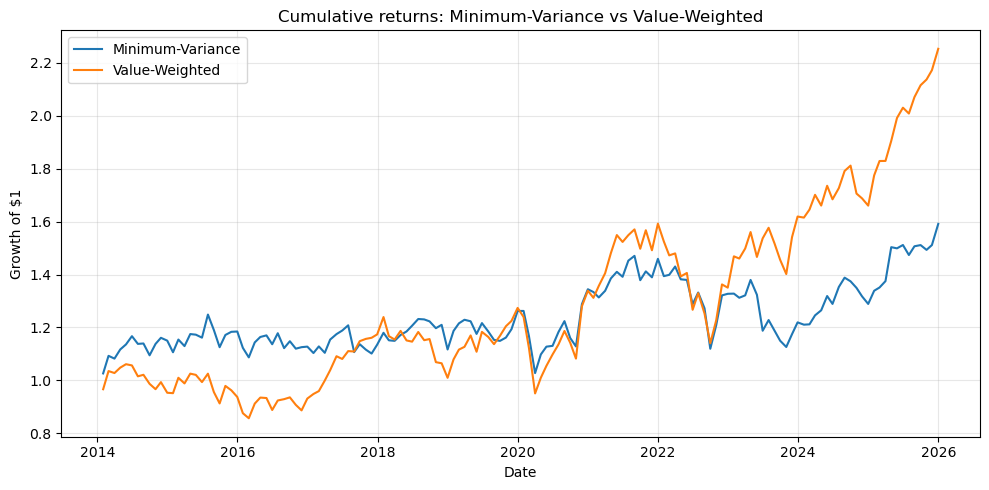

Done.
Outputs saved in: ..\results\outputs_vw

Return series check:
MV start: 2014-01-31 00:00:00
MV end:   2025-12-31 00:00:00
VW start: 2014-01-31 00:00:00
VW end:   2025-12-31 00:00:00
Number of months: 144

Summary statistics:
                  Annualized mean return  Annualized volatility  Sharpe ratio  Minimum monthly return  Maximum monthly return  Final cumulative index  Maximum drawdown  Number of monthly observations
Minimum-Variance                0.048285               0.137977      0.223107               -0.120156                0.141541                1.591446         -0.238776                           144.0
Value-Weighted                  0.080346               0.158463      0.397584               -0.152973                0.182863                2.253411         -0.283950                           144.0


In [65]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# This cell assumes Sections 2.1 and 2.2 have already been run
required_objects = [
    "years",
    "investment_sets",
    "year_end_dec",
    "ri_panel",
    "ret_panel",
    "mv_oos_returns",
    "rf_series"
]

for obj in required_objects:
    if obj not in globals():
        raise NameError(f"Missing object from previous sections: {obj}")


data_dir = Path("../data/cleaned")
mv_file = data_dir / "MV_M_cleaned.csv"

output_dir = Path("../results/outputs_vw")
output_dir.mkdir(parents=True, exist_ok=True)

csv_sep = ";"


def parse_calendar_date_headers(columns):
    cols = pd.Index(columns).astype(str).str.strip()
    return [pd.to_datetime(c, dayfirst=True) for c in cols]


def to_numeric_panel(df):
    return df.apply(
        lambda col: pd.to_numeric(
            col.astype(str).str.replace(",", ".", regex=False),
            errors="coerce"
        )
    )


def max_drawdown(cumulative_index):
    running_max = cumulative_index.cummax()
    drawdown = cumulative_index / running_max - 1.0
    return drawdown.min()


def perf_stats(r, rf):
    r = r.replace([np.inf, -np.inf], np.nan).dropna().copy()

    r_month = r.copy()
    r_month.index = r_month.index.to_period("M")

    rf_month = rf.copy()
    rf_month.index = rf_month.index.to_period("M")
    rf_aligned = rf_month.reindex(r_month.index)

    if rf_aligned.isna().sum() > 0:
        raise ValueError("Some RF observations are missing after monthly alignment.")

    excess = r_month - rf_aligned

    ann_mean = 12 * r_month.mean()
    ann_vol = np.sqrt(12) * r_month.std(ddof=1)

    if excess.std(ddof=1) != 0:
        sharpe = np.sqrt(12) * excess.mean() / excess.std(ddof=1)
    else:
        sharpe = np.nan

    cumulative_index = (1 + r).cumprod()

    return pd.Series({
        "Annualized mean return": ann_mean,
        "Annualized volatility": ann_vol,
        "Sharpe ratio": sharpe,
        "Minimum monthly return": r.min(),
        "Maximum monthly return": r.max(),
        "Final cumulative index": cumulative_index.iloc[-1],
        "Maximum drawdown": max_drawdown(cumulative_index),
        "Number of monthly observations": r.shape[0]
    })


# Load monthly market caps
mv_raw = pd.read_csv(mv_file, sep=csv_sep, na_values=["N/A", "#N/A", "nan", "NaN", ""])

mv_dates = parse_calendar_date_headers(list(mv_raw.columns[2:]))

mv_panel = mv_raw.copy()
mv_panel.columns = ["NAME", "ISIN"] + mv_dates
mv_panel = mv_panel.set_index(["ISIN", "NAME"])
mv_panel = to_numeric_panel(mv_panel)

# Keep the same sample end as the project
mv_panel = mv_panel.loc[:, mv_panel.columns <= pd.Timestamp("2025-12-31")]

# Keep only firms already used in the previous sections
common_mv_firms = mv_panel.index.intersection(ret_panel.index).intersection(ri_panel.index)
mv_panel = mv_panel.loc[common_mv_firms]

print("Monthly market cap panel shape:", mv_panel.shape)


# Build the same delisting map used in 2.2
# If a firm is clearly tagged as dead/delisted/suspended and the first missing RI month
# appears after the last valid observation, we treat that month as a -100% return.
delist_pattern = re.compile(r"DEAD|DELIST|SUSP", re.IGNORECASE)
delist_event_month = {}

for asset in ri_panel.index:
    isin, name = asset

    if not delist_pattern.search(name):
        continue

    ri_series = ri_panel.loc[asset]
    valid_dates = ri_series.dropna().index

    if len(valid_dates) == 0:
        continue

    last_valid_date = valid_dates.max()
    future_dates = [d for d in ri_panel.columns if d > last_valid_date]

    if len(future_dates) == 0:
        continue

    first_missing_date = future_dates[0]

    if pd.isna(ri_series[first_missing_date]):
        delist_event_month[asset] = first_missing_date


vw_rows = []

all_months = sorted(ret_panel.columns)

for Y in years:
    print(f"Formation year {Y} -> benchmark year {Y + 1}")

    eligible = investment_sets[Y]

    oos_months = [d for d in all_months if d.year == Y + 1]
    if len(oos_months) == 0:
        continue

    for dt in oos_months:
        current_loc = all_months.index(dt)
        prev_date = all_months[current_loc - 1]

        # Use previous-month market caps for current-month return
        caps_t = mv_panel.loc[eligible, prev_date].copy()
        r_t = ret_panel.loc[eligible, dt].copy()

        # Same delisting treatment as in 2.2
        forced_delist_assets = []
        for asset in r_t.index:
            if delist_event_month.get(asset) == dt and pd.isna(r_t.loc[asset]):
                forced_delist_assets.append(asset)

        if len(forced_delist_assets) > 0:
            r_t.loc[forced_delist_assets] = -1.0

        valid = (
            caps_t.notna()
            & np.isfinite(caps_t)
            & (caps_t > 0)
            & r_t.notna()
            & np.isfinite(r_t)
            & (r_t >= -1.0)
        )

        caps_t = caps_t[valid]
        r_t = r_t[valid]

        if len(caps_t) == 0:
            port_ret = np.nan
        else:
            w_t = caps_t / caps_t.sum()
            port_ret = float((w_t * r_t).sum())

        vw_rows.append({
            "date": dt,
            "formation_year": Y,
            "oos_year": Y + 1,
            "portfolio_return": port_ret
        })


vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

if vw_monthly_returns.empty:
    raise ValueError("No value-weighted returns were produced.")

vw_monthly_returns["date"] = pd.to_datetime(vw_monthly_returns["date"])
vw_monthly_returns = vw_monthly_returns[
    (vw_monthly_returns["date"] >= pd.Timestamp("2014-01-01")) &
    (vw_monthly_returns["date"] <= pd.Timestamp("2025-12-31"))
].copy()

vw_monthly_returns["cumulative_index"] = (1.0 + vw_monthly_returns["portfolio_return"]).cumprod()

vw_oos_returns = vw_monthly_returns.set_index("date")["portfolio_return"].sort_index()


# Put both strategies side by side
comparison_returns = pd.concat(
    [
        mv_oos_returns.rename("Minimum-Variance"),
        vw_oos_returns.rename("Value-Weighted")
    ],
    axis=1
).sort_index()

comparison_cumulative = (1.0 + comparison_returns).cumprod()

comparison_stats = pd.concat(
    [
        perf_stats(comparison_returns["Minimum-Variance"], rf_series).rename("Minimum-Variance"),
        perf_stats(comparison_returns["Value-Weighted"], rf_series).rename("Value-Weighted")
    ],
    axis=1
).T


# Save the main outputs
vw_monthly_returns.to_csv(output_dir / "vw_monthly_returns.csv", index=False)
comparison_returns.to_csv(output_dir / "comparison_monthly_returns.csv")
comparison_cumulative.to_csv(output_dir / "comparison_cumulative_returns.csv")
comparison_stats.to_csv(output_dir / "comparison_summary_stats.csv")


# Plot cumulative performance
plt.figure(figsize=(10, 5))
plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Minimum-Variance"],
    label="Minimum-Variance"
)
plt.plot(
    comparison_cumulative.index,
    comparison_cumulative["Value-Weighted"],
    label="Value-Weighted"
)

plt.title("Cumulative returns: Minimum-Variance vs Value-Weighted")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "graph_cumulative_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


print("Done.")
print(f"Outputs saved in: {output_dir}")

print("\nReturn series check:")
print("MV start:", comparison_returns["Minimum-Variance"].dropna().index.min())
print("MV end:  ", comparison_returns["Minimum-Variance"].dropna().index.max())
print("VW start:", comparison_returns["Value-Weighted"].dropna().index.min())
print("VW end:  ", comparison_returns["Value-Weighted"].dropna().index.max())
print("Number of months:", comparison_returns.shape[0])

print("\nSummary statistics:")
print(comparison_stats.to_string())

The value-weighted portfolio delivers a higher annualized return and a higher Sharpe ratio than the minimum-variance portfolio over the 2014–2025 out-of-sample period. However, it is also more volatile and experiences a larger maximum drawdown. By contrast, the minimum-variance portfolio achieves a smoother performance profile, but at the cost of lower return and lower risk-adjusted performance.

## **Part II - Portfolio Allocation with Carbon Emission Reduction**
**The second part of the project focuses on the climate impact of the portfolio.**
